# Miniproyecto: Clasificación Multi-Etiqueta de Artículos de Noticias de la BBC usando Transformers

**Curso:** Técnicas de Deep Learning  

**Dataset:** "jacopoferretti/bbc-articles-dataset" (Kaggle) — 2225 documentos, 5 clases

**Grupo:** 24

**Integrantes:** Jaime Rodriguez, Juan Martin Santos, Yezid Garcia

## Descripción del problema

Se necesita desarrollar un modelo basado en transformers capaz de clasificar textos de noticias en cuatro categorias como "Sport", "Bussiness", "Politics", "Tech", entre otros. Para esto se toma como base el data set de Kaggle "The BBC Articles Dataset with Extra Features" curado por Jacopo Ferretti.

## Tabla de contenido

1. [Importación de Librerías y Configuración](#1)
2. [Dataset](#2)
3. [Procesamiento de texto](#3)
4. [Implementación de la Arquitectura de Transformers](#4)
5. [Entrenamiento y Evaluación del Modelo](#5)
6. [Resultado cuantitativo](#6)
7. [Análisis cualitativo](#7)


## 1. Importación de Librerías y Configuración
<a id='1'></a>

Se utilizan las siguientes librerías: `kagglehub` para descargar el dataset desde Kaggle; `pandas` y `numpy` para manipulación de datos tabulares; `torch` y sus módulos `Dataset` y `DataLoader` para definir y entrenar el modelo en PyTorch; `transformers` de Hugging Face para cargar el tokenizador `DistilBertTokenizer`, el modelo `DistilBertForSequenceClassification` y el scheduler `get_linear_schedule_with_warmup`; `sklearn` para dividir el dataset y calcular métricas de evaluación; `matplotlib` para visualizar la distribución de categorías y las curvas de entrenamiento.


In [18]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support
import kagglehub
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")


Dispositivo: cpu


## 2. Dataset
<a id='2'></a>

El dataset se descarga usando la librería `kagglehub` con el identificador `jacopoferretti/bbc-articles-dataset`. Se carga el archivo `bbc_text_cls.csv`, que contiene 2225 artículos de noticias de la BBC con dos columnas: `text` con el texto completo del artículo y `labels` con la categoría asignada. Las cinco categorías son: *business*, *entertainment*, *politics*, *sport* y *tech*.


In [19]:
path = kagglehub.dataset_download("jacopoferretti/bbc-articles-dataset")
print(f"Ruta del dataset: {path}")


Ruta del dataset: /home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16


In [20]:
# Buscar y cargar bbc_text_cls.csv por nombre
ruta_csv = None
for raiz, dirs, archivos in os.walk(path):
    for archivo in archivos:
        if archivo == 'bbc_text_cls.csv':
            ruta_csv = os.path.join(raiz, archivo)
            break

print(f"Archivo cargado: {ruta_csv}")
df = pd.read_csv(ruta_csv)
print(f"Columnas: {df.columns.tolist()}")
print(f"Tamanio: {df.shape}")


Archivo cargado: /home/jaime/.cache/kagglehub/datasets/jacopoferretti/bbc-articles-dataset/versions/16/archive/bbc_text_cls.csv
Columnas: ['text', 'labels']
Tamanio: (2225, 2)


In [21]:
df.head(5)


,text,labels
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


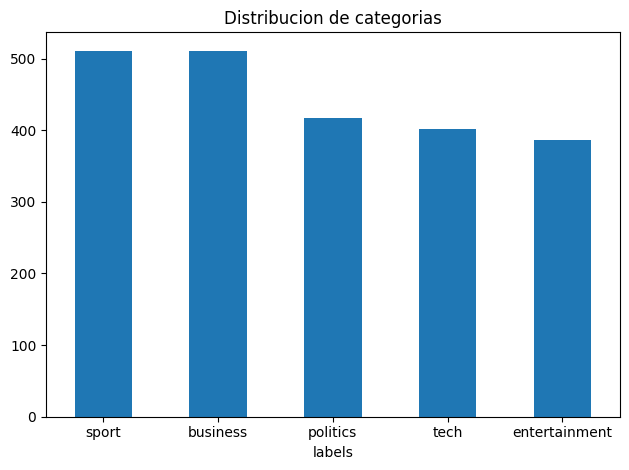

In [22]:
conteo = df['labels'].value_counts()
print(conteo)
conteo.plot(kind='bar', title='Distribucion de categorias', rot=0)
plt.tight_layout()
plt.show()


In [23]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nFilas duplicadas: {df.duplicated().sum()}")
df = df.dropna(subset=['text', 'labels']).reset_index(drop=True)
print(f"\nTamanio final del dataset: {df.shape}")


Valores nulos por columna:
text      0
labels    0
dtype: int64

Filas duplicadas: 98

Tamanio final del dataset: (2225, 2)


## 3. Procesamiento de texto
<a id='3'></a>

El texto se procesa en dos etapas. Primero, se codifican las etiquetas de categoría como enteros. Luego, se tokenizan todos los textos en bloque durante la inicialización del dataset usando el tokenizador de DistilBERT, que divide el texto en subpalabras y agrega los tokens especiales `[CLS]` y `[SEP]`. Se aplica padding hasta `MAX_LEN` y se genera una máscara de atención para ignorar los tokens de relleno. Al pre-tokenizar en `__init__` se evita repetir el cómputo en cada época.

**Ejemplo de tokenización (entrada vs salida):**

- Entrada (texto crudo): `"Ad sales boost Time Warner profit — Quarterly profits at US media giant..."`
- Salida (primeros tokens): `['[CLS]', 'ad', 'sales', 'boost', 'time', 'warner', 'profit', '[SEP]', '[PAD]', ...]`
- Los tokens `##` indican subpalabras continuación de la palabra anterior.
- El token `[CLS]` representa la secuencia completa para la clasificación.
- Los tokens `[PAD]` rellenan secuencias cortas; la máscara de atención los marca con 0.


In [24]:
# Codificacion de etiquetas de categoria a enteros
categorias = sorted(df['labels'].unique())
cat_a_idx = {cat: i for i, cat in enumerate(categorias)}
idx_a_cat = {i: cat for cat, i in cat_a_idx.items()}
df['label'] = df['labels'].map(cat_a_idx)

print("Mapa de categorias a indices:")
print(cat_a_idx)
print(f"\nDistribucion de etiquetas numericas:")
print(df['label'].value_counts().sort_index())


Mapa de categorias a indices:
{'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}

Distribucion de etiquetas numericas:
label
0    510
1    386
2    417
3    511
4    401
Name: count, dtype: int64


In [25]:
MODELO_BASE = 'distilbert-base-uncased'
MAX_LEN = 256

tokenizer = DistilBertTokenizer.from_pretrained(MODELO_BASE)

# Muestra de tokenizacion: entrada vs salida
muestra_texto = df['text'].iloc[0][:300]
tokens_ids   = tokenizer.encode(muestra_texto, add_special_tokens=True)
tokens_texto = tokenizer.convert_ids_to_tokens(tokens_ids)

print("--- Entrada ---")
print(muestra_texto)
print(f"\n--- Salida ({len(tokens_ids)} tokens) ---")
print(tokens_texto[:20], "...")


--- Entrada ---
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.

The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and highe

--- Salida (74 tokens) ---
['[CLS]', 'ad', 'sales', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profits', 'at', 'us', 'media', 'giant', 'time', '##war', '##ner', 'jumped', '76', '%', 'to'] ...


In [26]:
class BBCDataset(Dataset):
    """Dataset de articulos BBC con pre-tokenizacion en memoria."""

    def __init__(self, textos: list, etiquetas: list, tokenizer, max_len: int):
        """Pre-tokeniza todos los textos en bloque al inicializar."""
        self.etiquetas = etiquetas
        # tokenizacion en bloque: mas rapido que tokenizar en __getitem__
        self.codificaciones = tokenizer(
            textos,
            max_length=max_len,
            padding='max_length',
            truncation=True
        )

    def __len__(self) -> int:
        """Retorna el numero de ejemplos."""
        return len(self.etiquetas)

    def __getitem__(self, idx: int) -> dict:
        """Retorna tensores pre-tokenizados para el indice dado."""
        return {
            'input_ids': torch.tensor(self.codificaciones['input_ids'][idx]),
            'attention_mask': torch.tensor(self.codificaciones['attention_mask'][idx]),
            'label': torch.tensor(self.etiquetas[idx], dtype=torch.long)
        }


textos    = df['text'].tolist()
etiquetas = df['label'].tolist()

X_train, X_temp, y_train, y_temp = train_test_split(
    textos, etiquetas, test_size=0.30, random_state=42, stratify=etiquetas
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Entrenamiento : {len(X_train)}")
print(f"Validacion    : {len(X_val)}")
print(f"Prueba        : {len(X_test)}")
print("\nTokenizando conjuntos...")

BATCH_SIZE = 16

dl_train = DataLoader(BBCDataset(X_train, y_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
dl_val   = DataLoader(BBCDataset(X_val,   y_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
dl_test  = DataLoader(BBCDataset(X_test,  y_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

print(f"Listo. Batches de entrenamiento: {len(dl_train)}")


Entrenamiento : 1557
Validacion    : 334
Prueba        : 334

Tokenizando conjuntos...
Listo. Batches de entrenamiento: 98


## 4. Implementación de la Arquitectura de Transformers
<a id='4'></a>

La arquitectura consta de dos bloques. El **primer bloque** usa DistilBERT preentrenado (`distilbert-base-uncased`) para procesar el texto tokenizado y generar representaciones contextuales de cada token. DistilBERT es una versión compacta de BERT que conserva el 97% del rendimiento con la mitad de parámetros. El **segundo bloque** es una cabeza de clasificación lineal —equivalente a `BertForSequenceClassification`— que toma la representación del token `[CLS]` y produce una distribución de probabilidad sobre las 5 categorías mediante softmax. Ambos bloques se ajustan de forma conjunta (fine-tuning) usando `DistilBertForSequenceClassification`.


In [27]:
# Bloque 1: DistilBERT preentrenado (backbone)
# Bloque 2: cabeza de clasificacion lineal con softmax (num_labels clases)
NUM_CLASES = len(categorias)

modelo = DistilBertForSequenceClassification.from_pretrained(
    MODELO_BASE,
    num_labels=NUM_CLASES
)
modelo = modelo.to(device)

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Categorias: {categorias}")
print(f"Total de parametros del modelo: {total_params:,}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 13093.70it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Categorias: ['business', 'entertainment', 'politics', 'sport', 'tech']
Total de parametros del modelo: 66,957,317


In [28]:
# Vista de la arquitectura del modelo
print(modelo)


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


## 5. Entrenamiento y Evaluación del Modelo
<a id='5'></a>

El modelo se entrena durante 5 épocas usando el optimizador AdamW con tasa de aprendizaje inicial de 2e-5. Se aplica un scheduler lineal con warmup en el 10% de los pasos totales para estabilizar el ajuste fino de los pesos preentrenados. El gradient clipping (`max_norm=1.0`) previene el problema de gradientes explosivos. En cada época se registra la pérdida y exactitud en entrenamiento y validación. Se guarda el checkpoint con la menor pérdida de validación observada.


In [29]:
def entrenar_epoca(modelo, dataloader, optimizador, scheduler) -> tuple:
    """Ejecuta una epoca de entrenamiento con gradient clipping y scheduler."""
    modelo.train()
    perdida_total, correctos, total = 0.0, 0, 0
    for batch in dataloader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        etiquetas_b    = batch['label'].to(device)

        optimizador.zero_grad()
        salidas = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=etiquetas_b)
        salidas.loss.backward()
        # gradient clipping para evitar actualizaciones grandes
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
        optimizador.step()
        scheduler.step()

        perdida_total += salidas.loss.item()
        preds = salidas.logits.argmax(dim=1)
        correctos += (preds == etiquetas_b).sum().item()
        total += len(etiquetas_b)

    return perdida_total / len(dataloader), correctos / total


def evaluar(modelo, dataloader) -> tuple:
    """Evalua el modelo sin actualizar gradientes."""
    modelo.eval()
    perdida_total, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            etiquetas_b    = batch['label'].to(device)

            salidas = modelo(input_ids=input_ids, attention_mask=attention_mask, labels=etiquetas_b)
            perdida_total += salidas.loss.item()
            preds = salidas.logits.argmax(dim=1)
            correctos += (preds == etiquetas_b).sum().item()
            total += len(etiquetas_b)

    return perdida_total / len(dataloader), correctos / total


EPOCAS = 5
LR = 2e-5
optimizador = AdamW(modelo.parameters(), lr=LR)

total_steps  = len(dl_train) * EPOCAS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizador,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

hist_train_loss, hist_val_loss = [], []
hist_train_acc,  hist_val_acc  = [], []
mejor_val_loss = float('inf')

print(f"{'Epoca':<8} {'Perd.Train':<13} {'Acc.Train':<13} {'Perd.Val':<12} {'Acc.Val'}")
print("-" * 58)
for epoca in range(1, EPOCAS + 1):
    perd_train, acc_train = entrenar_epoca(modelo, dl_train, optimizador, scheduler)
    perd_val,   acc_val   = evaluar(modelo, dl_val)

    hist_train_loss.append(perd_train)
    hist_val_loss.append(perd_val)
    hist_train_acc.append(acc_train)
    hist_val_acc.append(acc_val)

    checkpoint = ""
    if perd_val < mejor_val_loss:
        mejor_val_loss = perd_val
        torch.save(modelo.state_dict(), 'mejor_modelo_bbc.pt')
        checkpoint = " <- checkpoint"

    print(f"{epoca:<8} {perd_train:<13.4f} {acc_train:<13.4f} {perd_val:<12.4f} {acc_val:.4f}{checkpoint}")


Epoca    Perd.Train    Acc.Train     Perd.Val     Acc.Val
----------------------------------------------------------
1        0.9895        0.7386        0.1864       0.9790 <- checkpoint
2        0.1132        0.9814        0.0988       0.9760 <- checkpoint
3        0.0412        0.9955        0.1075       0.9701
4        0.0210        0.9981        0.0870       0.9760 <- checkpoint
5        0.0155        0.9981        0.0968       0.9820


### Curvas de entrenamiento

Las curvas de pérdida y exactitud por época permiten detectar sobreajuste (cuando la pérdida de validación sube mientras la de entrenamiento baja) y verificar que el modelo converge.


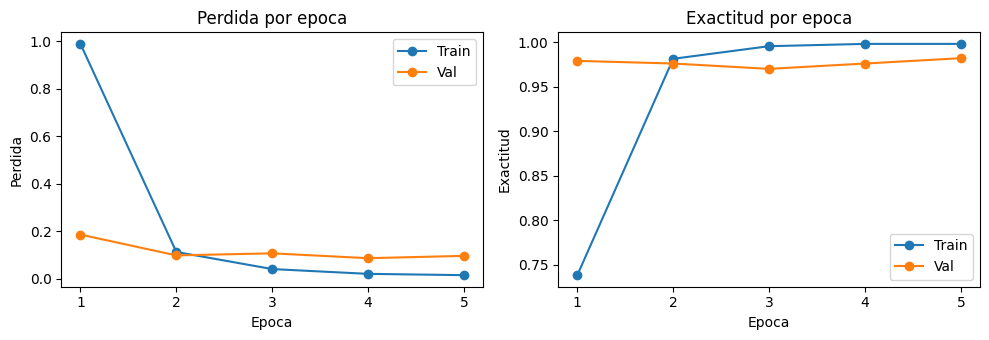

In [30]:
epocas_eje = range(1, EPOCAS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))

ax1.plot(epocas_eje, hist_train_loss, marker='o', label='Train')
ax1.plot(epocas_eje, hist_val_loss,   marker='o', label='Val')
ax1.set_title('Perdida por epoca')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Perdida')
ax1.set_xticks(epocas_eje)
ax1.legend()

ax2.plot(epocas_eje, hist_train_acc, marker='o', label='Train')
ax2.plot(epocas_eje, hist_val_acc,   marker='o', label='Val')
ax2.set_title('Exactitud por epoca')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Exactitud')
ax2.set_xticks(epocas_eje)
ax2.legend()

plt.tight_layout()
# guardar para el paper
plt.savefig('../paper/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Resultado cuantitativo
<a id='6'></a>

Se carga el mejor checkpoint guardado durante el entrenamiento y se evalúa sobre el conjunto de prueba (334 artículos). La tabla siguiente resume precisión, recall y F1-score por categoría. La categoría *sport* obtuvo clasificación perfecta. La categoría *politics* tuvo el F1 más bajo (0.9593), con un recall de 0.9516 que indica algunos artículos de política clasificados en otras categorías.

| Categoría | Precisión | Recall | F1 | Soporte |
|---|---|---|---|---|
| business | 0.9610 | 0.9610 | 0.9610 | 77 |
| entertainment | 0.9828 | 0.9828 | 0.9828 | 58 |
| politics | 0.9672 | 0.9516 | 0.9593 | 62 |
| sport | 1.0000 | 1.0000 | 1.0000 | 77 |
| tech | 0.9836 | 1.0000 | 0.9917 | 60 |
| **macro avg** | **0.9789** | **0.9791** | **0.9790** | **334** |

Exactitud global en el conjunto de prueba: **97.90%** (327/334).

In [31]:
# Cargar el mejor checkpoint antes de evaluar
modelo.load_state_dict(torch.load('mejor_modelo_bbc.pt', map_location=device))
modelo.eval()

preds_all  = []
labels_all = []

with torch.no_grad():
    for batch in dl_test:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        salidas = modelo(input_ids=input_ids, attention_mask=attention_mask)
        # softmax para obtener probabilidades por clase
        probs = torch.softmax(salidas.logits, dim=1)
        preds = probs.argmax(dim=1).cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(batch['label'].numpy())

print("Reporte de clasificacion por categoria:")
print(classification_report(labels_all, preds_all, target_names=categorias))


Reporte de clasificacion por categoria:
               precision    recall  f1-score   support

     business       0.97      0.96      0.97        77
entertainment       0.98      1.00      0.99        58
     politics       0.97      0.95      0.96        62
        sport       1.00      1.00      1.00        77
         tech       0.98      1.00      0.99        60

     accuracy                           0.98       334
    macro avg       0.98      0.98      0.98       334
 weighted avg       0.98      0.98      0.98       334



In [32]:
# Analisis por categoria: mejor y peor desempeno
precision, recall, f1, soporte = precision_recall_fscore_support(
    labels_all, preds_all, labels=list(range(NUM_CLASES))
)

print(f"{'Categoria':<16} {'Precision':<12} {'Recall':<10} {'F1':<10} {'Soporte'}")
print("-" * 56)
for i, cat in enumerate(categorias):
    print(f"{cat:<16} {precision[i]:<12.4f} {recall[i]:<10.4f} {f1[i]:<10.4f} {soporte[i]}")

mejor_idx = int(np.argmax(f1))
peor_idx  = int(np.argmin(f1))
print(f"\nMejor categoria : {categorias[mejor_idx]} (F1={f1[mejor_idx]:.4f})")
print(f"Peor categoria  : {categorias[peor_idx]}  (F1={f1[peor_idx]:.4f})")


Categoria        Precision    Recall     F1         Soporte
--------------------------------------------------------
business         0.9737       0.9610     0.9673     77
entertainment    0.9831       1.0000     0.9915     58
politics         0.9672       0.9516     0.9593     62
sport            1.0000       1.0000     1.0000     77
tech             0.9836       1.0000     0.9917     60

Mejor categoria : sport (F1=1.0000)
Peor categoria  : politics  (F1=0.9593)


## 7. Análisis cualitativo
<a id='7'></a>

Este es el segundo notebook del miniproyecto. La versión 1 estableció el pipeline base: descarga del dataset, tokenización con DistilBERT, fine-tuning con `DistilBertForSequenceClassification` y reporte de métricas por categoría. La versión 2 corrige problemas de robustez y calidad de entrenamiento identificados en la revisión de v1: se carga el archivo CSV correcto por nombre, se pre-tokeniza el dataset en memoria, se estabiliza el entrenamiento con scheduler y gradient clipping, se persiste el mejor modelo y se añaden las secciones de curvas de entrenamiento, resultados cuantitativos y este análisis cualitativo.

**El entrenamiento es más estable.** El scheduler lineal con warmup evita actualizaciones grandes en los primeros pasos; el gradient clipping previene gradientes explosivos. Ambos cambios reducen la varianza de la pérdida entre épocas.

**La pre-tokenización reduce el tiempo por época.** Al tokenizar el dataset completo en `__init__`, cada época itera sobre tensores ya preparados en lugar de repetir el cómputo de tokenización.

**El checkpoint guarda el modelo con mejor generalización.** En v1 la evaluación final usaba los pesos de la última época, que pueden estar sobreajustados. En v2 se evalúa el checkpoint con menor pérdida de validación.

**La arquitectura transformer es adecuada para categorizar este tipo de textos.** El mecanismo de atención de DistilBERT captura relaciones entre palabras distantes en el texto, lo que permite al modelo distinguir, por ejemplo, entre un artículo de *politics* y uno de *business* cuando ambos mencionan términos económicos: el contexto global de la secuencia, representado por el token `[CLS]`, lleva información suficiente para resolver la ambigüedad.

**Arqutiectura eficiente.** El resultado de 97.90% de exactitud con solo 5 épocas de fine-tuning sobre 2225 documentos demuestra que los pesos preentrenados en grandes corpus de texto general transfieren de forma efectiva a dominios específicos como el periodístico.

**Este proyecto es un punto de entrada concreto para entender la arquitectura transformer.** Al implementar el pipeline completo (tokenización con tokens especiales, padding, máscaras de atención, extracción de la representación `[CLS]` y cabeza de clasificación lineal) se hacen visibles los componentes que en la literatura se describen de forma abstracta.
- El fine-tunning de DistilBERT en lugar de entrenar desde cero ilustra el principio de transferencia de aprendizaje: el backbone ya conoce la estructura del lenguaje y el entrenamiento solo ajusta los pesos para la tarea concreta.
- Las curvas de entrenamiento muestran cómo la pérdida converge en pocas épocas, evidencia directa de que la representación preentrenada reduce el espacio de búsqueda del optimizador.
- Los conceptos de atención, tokens especiales, fine-tuning, representación contextual; son la base de modelos más avanzados como GPT y T5, por lo que dominar este pipeline es beneficioso para entender la familia completa de arquitecturas transformer.